# Dataset Description
## Correlation between Minimum Wage Growth and inflation growth
**Source**: Banco de la república, DANE

**Inflation**: [link](https://suameca.banrep.gov.co/estadisticas-economicas/tablasPreconstruidas)

**Minimum Wage**: [link](https://suameca.banrep.gov.co/estadisticas-economicas/tablasPreconstruidas)

# Code
## Imports

In [143]:
import pandas as pd
import matplotlib.pyplot as plt
from highlight_text import fig_text
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pathlib import Path
import matplotlib.patches as mpatches

pd.set_option("display.float_format", lambda x: "%.2f" % x)

BASE_DIR = Path.cwd().parent.parent

## Load data

In [144]:
path_inflation = "./data/Total_Nacional.csv"
path_wage = "./data/salario_minimo.csv"

logo_path = BASE_DIR / "logo/logo.png"

df_cpi = pd.read_csv(path_inflation, encoding="utf-8", usecols=[0,2])
df_wage = pd.read_csv(path_wage, encoding="utf-8", usecols=[0,1])

logo = plt.imread(logo_path)

## Clean Data

In [145]:
def filter_df(dataset: pd.DataFrame, city: str) -> pd.DataFrame:
    df = dataset.copy()

    df["Fecha"] = pd.to_datetime(df["Fecha"])

    df_f = df[
        (df["Fecha"].dt.year >= 1984) & (df["Fecha"].dt.year < 2026) & 
        ((df["Fecha"].dt.month == 12))
    ].rename(columns={"Variación anual (%)": f"Inflation {city}"})

    df_f["Fecha"] = df_f["Fecha"].dt.year

    df_f.sort_values(by=["Fecha"], ascending=True, inplace=True)

    return df_f

national = filter_df(df_cpi, "national")

growth_wage = pd.DataFrame({
    "Fecha": df_wage["Fecha"],
    "growth_wage": df_wage["Salario"].pct_change() * 100
})

growth = pd.merge(national, growth_wage, on="Fecha", how="inner").dropna()

## Plot

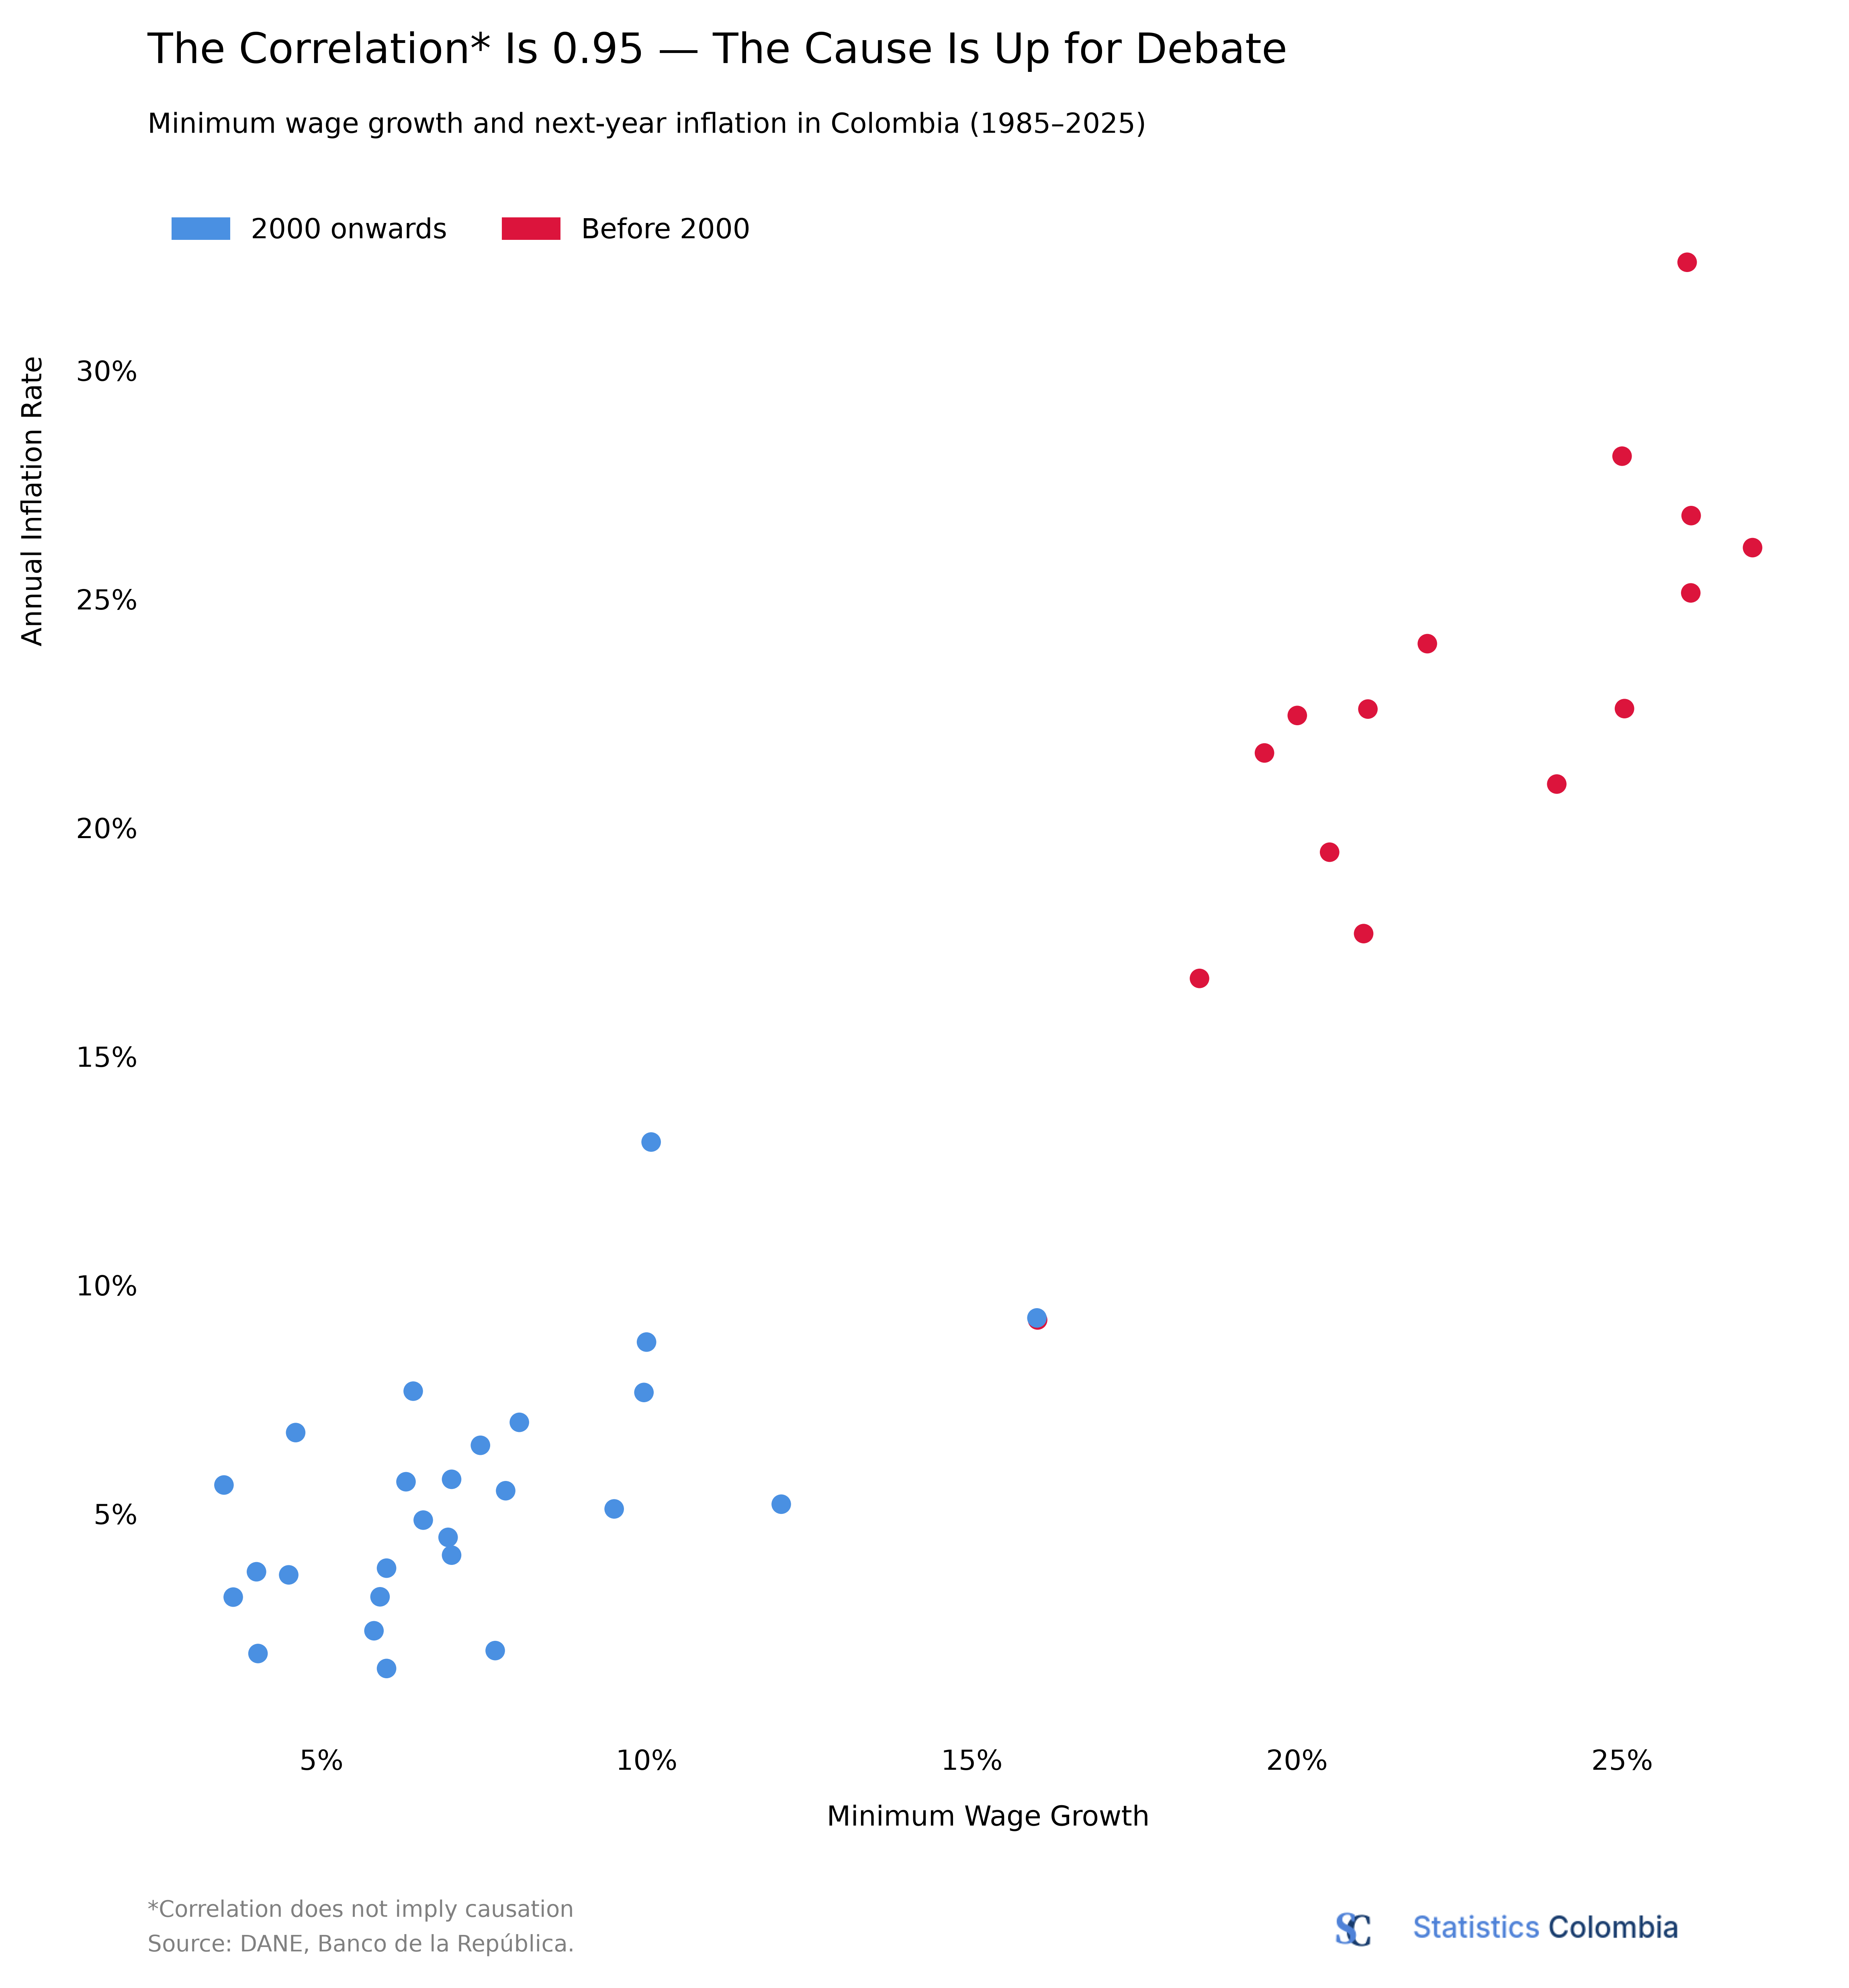

In [153]:
x = growth["growth_wage"] 
y = growth["Inflation national"]
red = "#DC143C"
blue = "#4a90e2" 

plt.figure(figsize=(10.8, 10), dpi=500)

colors = [red if year < 2000 else blue for year in growth["Fecha"]]

plt.scatter(x, y, color=colors)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.xlabel("Minimum Wage Growth", labelpad=10, fontsize=10)
plt.ylabel("Annual Inflation Rate", labelpad=10, fontsize=10, y=0.8)

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

correlation = x.corr(y, method="pearson")

fig_text(
    x=0.125, y=0.96,
    s=f"The Correlation* Is {correlation:.2f} — The Cause Is Up for Debate",
    fontsize=15
)

fig_text(
    x=0.125, y=0.92,
    s="Minimum wage growth and next-year inflation in Colombia (1985–2025)",
    fontsize=10
)

fig_text(
    0.125, 0.03, 
    "*Correlation does not imply causation\n"
    "Source: DANE, Banco de la República.", 
    fontsize=8, color="gray",
)

imagebox = OffsetImage(logo, zoom=0.4)

ab = AnnotationBbox(imagebox, xy=(0.7, 0.03), xycoords="figure fraction",
                    frameon=False, pad=0)

plt.gca().add_artist(ab)

pre2000 = mpatches.Patch(color=red, label="Before 2000")
post2000 = mpatches.Patch(color=blue, label="2000 onwards")
plt.legend(handles=[post2000, pre2000], loc="upper left", frameon=False, ncol=2)

plt.show()